# P2: Sentiment klassifikatori — hissiyot tahlili

**Mavzu:** Logistic Regression, Naive Bayes, TF-IDF va baholash metrikalari  
**Kun:** 3-kun amaliyoti — 18-iyun 2026, 09:30-10:50 (80 daqiqa)  
**Juftlashgan ma'ruza:** L2 — Klassik usullar bilan matn tasnifi ([PDF](../lectures/d02_klassik_tasnif_grafikli.pdf))  
**Ma'lumot:** Uzum Market sharhlari (`d03_checkpoints/uzum_uz_clean.txt`)  
**GPU:** kerak emas; Kaggle CPU yetarli.

Bugungi amaliyotda kechagi `TextPreprocessor` capstone modulini sentiment klassifikatorga ulaymiz: sharhlar -> `ijobiy/salbiy` yorliqlar -> TF-IDF -> Logistic Regression / Naive Bayes -> metrikalar.

**Bugungi maqsadlar:**
1. Reytinglarni `ijobiy` / `salbiy` yorliqlariga aylantirish.
2. Train/test split va Day 2 `TextPreprocessor` natijasidan TF-IDF feature matritsa qurish.
3. Naive Bayes ni qo'lda hisoblab, L2 [I2]-slayd natijasini tekshirish (`ratio ~= 3.375`).
4. Logistic Regression va MultinomialNB modellarini o'qitish.
5. Precision, recall, F1, confusion matrix va xato tahlili qilish.
6. Oxirida `SentimentClassifier` klassi qanday ko'rinishini yengil ko'rish.

| Bo'lim | Tavsif | Vaqt |
|---:|---|---:|
| 1 | Muhit va dataset | 5 daq |
| 2 | Yaxlit natija | 8 daq |
| 3 | Binarizatsiya, split, TF-IDF | 15 daq |
| 4 | NB qo'lda, LR/NB, metrikalar | 35 daq |
| 5 | Yengil capstone preview | 10 daq |
| 6 | Tadqiqot + yakun | 7 daq |

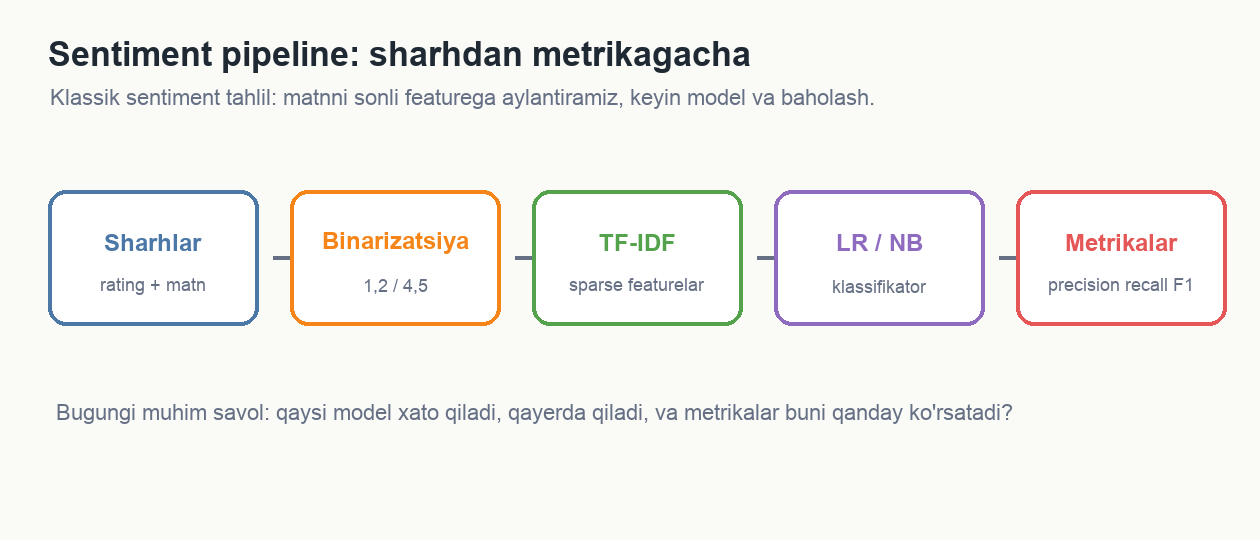


In [2]:
# Paketlar haqida qisqa izoh
# Kaggle CPU runtime odatda kerakli paketlarni allaqachon beradi.
# Ishlatamiz: numpy, pandas, matplotlib, scikit-learn.
# GPU, PyTorch, Hugging Face bu darsda kerak emas.


In [3]:
# ============================================================
# 1. Muhit tekshiruvi va P1 capstone preprocessorini qayta ishlatish
# ============================================================
import re, random, sys
from pathlib import Path
import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

OFFLINE_FALLBACK = True
SAVE_CAPSTONE_MODULE = False  # True -> m02_sentiment_classifier.py faylga yoziladi (ixtiyoriy)

try:
    import sklearn, matplotlib
    import matplotlib.pyplot as plt
    print(f"Python      : {sys.version.split()[0]}")
    print(f"scikit-learn: {sklearn.__version__}")
    print(f"numpy       : {np.__version__}")
    print(f"matplotlib  : {matplotlib.__version__}")
except ImportError as exc:
    raise ImportError("Kaggle CPU runtime tanlang; scikit-learn/pandas/matplotlib kerak bo'ladi.") from exc

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 90)


def find_m01_module_dir() -> Path | None:
    """Day 2 capstone modulini lokal, Kaggle working yoki Kaggle input ichidan qidiradi."""
    candidates = [
        Path('capstone/modules'),
        Path('../capstone/modules'),
        Path('/kaggle/working/capstone/modules'),
    ]
    kaggle_root = Path('/kaggle/input')
    if kaggle_root.exists():
        candidates.extend(path.parent for path in kaggle_root.rglob('m01_text_preprocessor.py'))
    return next((path for path in candidates if (path / 'm01_text_preprocessor.py').exists()), None)

m01_dir = find_m01_module_dir()
if m01_dir is not None:
    sys.path.insert(0, str(m01_dir.resolve()))
    from m01_text_preprocessor import TextPreprocessor
    PREPROCESSOR_SOURCE = f"m01 TextPreprocessor: {m01_dir}"
else:
    # Kaggle demo fallback: agar P1 capstone fayli upload qilinmagan bo'lsa ham notebook ishlaydi.
    _APO = re.compile(r"['’‘ʼʻ]")
    _TOK = re.compile(r"[a-z][a-z']*")
    _STOP = {
        'va', 'bu', 'bir', 'ham', 'lekin', 'uchun', 'bilan', 'ga', 'da',
        'ni', 'dan', 'ning', 'men', 'sen', 'biz', 'siz', 'ular',
    }

    class TextPreprocessor:
        def preprocess(self, text: str) -> list[str]:
            if not isinstance(text, str) or not text.strip():
                raise ValueError("text bo'sh bo'lmasligi kerak")
            text = _APO.sub("'", text.lower())
            return [w for w in _TOK.findall(text) if w not in _STOP and len(w) > 1]

        def preprocess_batch(self, texts: list[str]) -> list[list[str]]:
            return [self.preprocess(text) for text in texts]

        def fit_stopwords(self, texts: list[str], max_df: float = 0.85) -> None:
            return None

    PREPROCESSOR_SOURCE = "fallback mini TextPreprocessor (P1 fayli topilmadi)"

preprocessor = TextPreprocessor()


def preprocess(text: str) -> list[str]:
    """P1 TextPreprocessor orqali tokenlar qaytaradi."""
    return preprocessor.preprocess(text)


def to_str(text: str) -> str:
    """TF-IDF uchun P1 tokenlarini bo'sh joy bilan birlashtiradi."""
    if not isinstance(text, str) or not text.strip():
        return ''
    return ' '.join(preprocess(text))

UZ_SENTIMENT_FALLBACK = [
    ('5', "ovozi ham zo'r baland uzumga rahmat"),
    ('5', 'judayam qiziqarli kitob ekan uzumga raxmat'),
    ('5', "juda zo'r barcha onalarga tavsiya qilaman"),
    ('5', 'tami yaxshi ekan raxmat maza kildim'),
    ('5', 'raxmat kottakon. zor ekan yana arzon. narxni kotarib yubormasangiz klent bolamiz'),
    ('5', "hamma narsasi joyida keldi. ishlashi ham zo'r. sotuvchi va uzum market hodimlariga katta rahmat"),
    ('5', "bemalol olsez bo'ladi zo'r ekan manga yoqdi"),
    ('5', "kitob yaxshi xolatda, chiroyli ko'rinishda etib keldi, raxmat"),
    ('5', 'kaxva ajoyib, bu pulga juda yaxshi sifat bor ekan'),
    ('5', 'chiroyli soat ekan ishlayabdi yaxshi holatda keldi narxi ham arzongina'),
    ('4', 'yaxshi mahsulot keldi, narxi ham qulay, yana buyurtma beraman'),
    ('4', 'sifati yaxshi, faqat yetkazish biroz kechikdi, lekin mamnunman'),
    ('1', 'olib ochishim bilan ishlatdim va bitta kulogi iglamadi'),
    ('1', 'sifati yaxshi emas juda yuqa'),
    ('1', "bir marta taqib ko'rdim rangi ochib ketdi, juda kichkina"),
    ('1', "sifatsiz narsa, insofi yo'q ishlab chiqaruvchilar"),
    ('1', "narhi qimmat, juda sifatlisini kutgandik, hafsalam pir bo'ldi"),
    ('1', "yaroqsiz chiqdi, pulim ham to'liq qaytarib berilmadi"),
    ('1', "afzalliklari yo'q, bir tiyinga qimmat, bekordan bekor pul ketdi"),
    ('2', 'narxi arzon lekin sifati umuman yaxshi emas, hafsalam pir'),
    ('2', 'kechikdi va kelganda ham shikastlangan edi, rozi emasman'),
    ('2', "rasmdagidan butunlay boshqa narsa keldi, juda xafa bo'ldim"),
    ('2', "buyurtma berganim bilan kelmadi, kuzatib turganim ham bo'lmadi"),
    ('2', 'ishlab chiqarish sifati past, umuman tavsiya etmayman bu mahsulotni'),
]

print()
print(f"Muhit tayyor. Preprocessor: {PREPROCESSOR_SOURCE}")
print(f"Ichki fallback: {len(UZ_SENTIMENT_FALLBACK)} namuna sharh.")


Python      : 3.12.13
scikit-learn: 1.6.1
numpy       : 2.0.2
matplotlib  : 3.10.0

Muhit tayyor. Preprocessor: fallback mini TextPreprocessor (P1 fayli topilmadi)
Ichki fallback: 24 namuna sharh.


## 2. Yaxlit natija — pirovard manzil birinchi!

Quyida **tugallangan sentiment pipeline** bir necha satrda ishga tushadi:
sharhlar → binarizatsiya → tozalash → TF-IDF → LogisticRegression → bashorat.
Hozir tushuntirishdan oldin — natijani ko'ring.


In [5]:
# Pirovard natija (5-bo'limda quriladigan m02 ning soddalashtirilgan versiyasi)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def _binarize0(r):
    r = int(r)
    return 'ijobiy' if r >= 4 else ('salbiy' if r <= 2 else None)

_rows = UZ_SENTIMENT_FALLBACK
_t, _l = [], []
for rat, txt in _rows:
    lab = _binarize0(rat)
    if lab:
        _t.append(txt); _l.append(lab)

_vec0 = TfidfVectorizer()
_X0   = _vec0.fit_transform([to_str(t) for t in _t])
_clf0 = LogisticRegression(max_iter=1000).fit(_X0, _l)

_sample = "Mahsulot juda sifatli, tez yetkazib berishdi, rahmat."
_pred   = _clf0.predict(_vec0.transform([to_str(_sample)]))[0]
print(f"Korpus   : {len(_t)} sharh ({_l.count('ijobiy')} ijobiy / {_l.count('salbiy')} salbiy)")
print(f"Namuna   : '{_sample}'")
print(f"Bashorat : {_pred.upper()}")
print("\n✓ Pipeline ishladi! Quyida har bir qadamni o'rganamiz.")


Korpus   : 24 sharh (12 ijobiy / 12 salbiy)
Namuna   : 'Mahsulot juda sifatli, tez yetkazib berishdi, rahmat.'
Bashorat : IJOBIY

✓ Pipeline ishladi! Quyida har bir qadamni o'rganamiz.


## 3. Tayyor kod bloki — PRIMM

### 3A. Ma'lumotni yuklash va binarizatsiya

> **Bashorat qiling** — kodni ishlatishdan oldin javob bering:
> Reyting 1–5 ni ikkilik (ijobiy/salbiy) yorliqqa aylantirsak, reyting **3**
> bilan nima qilamiz? Nega?

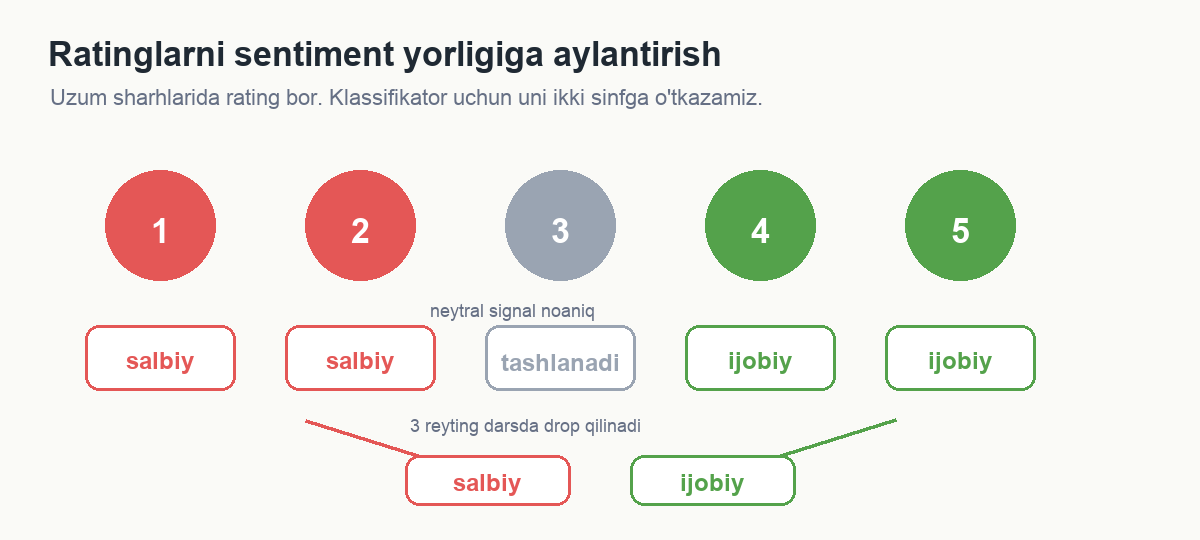


In [6]:
# To'liq berilgan kod (PRIMM — periphery)
# Offline: d03_checkpoints/uzum_uz_clean.txt yoki Kaggle dataset ichidagi shu fayl.

from collections import Counter


def find_data_file(filename: str = 'uzum_uz_clean.txt') -> Path | None:
    candidates = []
    kaggle_root = Path('/kaggle/input')
    if kaggle_root.exists():
        candidates.extend(kaggle_root.rglob(filename))
    candidates.extend([
        Path('d03_checkpoints') / filename,
        Path('practices/d03_checkpoints') / filename,
        Path('../practices/d03_checkpoints') / filename,
        Path(filename),
    ])
    return next((path for path in candidates if path.exists()), None)

DATA_FILE = find_data_file('uzum_uz_clean.txt')
TAB = chr(9)

def binarize_rating(rating) -> str | None:
    """Reyting 1-5 -> ikkilik yorliq. {4,5}->ijobiy, {1,2}->salbiy, 3 tashlanadi."""
    r = int(rating)
    if r >= 4:
        return 'ijobiy'
    if r <= 2:
        return 'salbiy'
    return None

if DATA_FILE is not None:
    source = f'fayl: {DATA_FILE}'
    raw_rows = [
        tuple(line.split(TAB, 1))
        for line in DATA_FILE.read_text(encoding='utf-8').splitlines()
        if line.strip() and TAB in line
    ]
elif OFFLINE_FALLBACK:
    source = 'ichki fallback namuna'
    raw_rows = UZ_SENTIMENT_FALLBACK
else:
    raise FileNotFoundError("uzum_uz_clean.txt topilmadi. Kaggle dataset biriktirilganini tekshiring.")

texts, labels = [], []
n_dropped = 0
for rating, text in raw_rows:
    lab = binarize_rating(rating)
    if lab is None:
        n_dropped += 1
        continue
    texts.append(text)
    labels.append(lab)

label_counts = Counter(labels)
print(f'Manba         : {source}')
print(f"Jami o'qildi : {len(raw_rows)} qator")
print(f'Tashlandi (3): {n_dropped} neytral sharh')
print(f"Qoldi        : {len(texts)} sharh  (ijobiy: {label_counts['ijobiy']}, salbiy: {label_counts['salbiy']})")
print(f'Namuna       : [{labels[0]}] {texts[0]!r}')

pd.DataFrame({'label': labels}).value_counts().rename('count').reset_index()


Manba         : ichki fallback namuna
Jami o'qildi : 24 qator
Tashlandi (3): 0 neytral sharh
Qoldi        : 24 sharh  (ijobiy: 12, salbiy: 12)
Namuna       : [ijobiy] "ovozi ham zo'r baland uzumga rahmat"


,label,count
0,ijobiy,12
1,salbiy,12


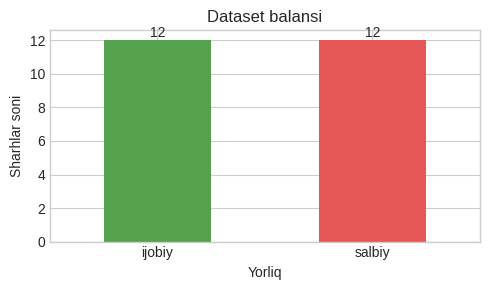

In [7]:
# Vizual tekshiruv: sinf balansi
label_df = pd.DataFrame({'label': labels})
counts = label_df['label'].value_counts().reindex(['ijobiy', 'salbiy'])
ax = counts.plot(kind='bar', color=['#54A24B', '#E45756'], figsize=(5, 3), rot=0)
ax.set_title('Dataset balansi')
ax.set_xlabel('Yorliq')
ax.set_ylabel('Sharhlar soni')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


> **Tekshiring:**
> 1. Nechta sharh qoldi va ijobiy/salbiy nisbati qanday?
> 2. `binarize_rating(3)` nimani qaytaradi? Nega `None` foydali?
> 3. Sinflar muvozanatli (balanced) mi? Bu muhimmi — nima uchun?

> **O'zgartiring — shaxsiy tajriba!**
> `binarize_rating` ni o'zgartiring: reyting 3 ni ham `'ijobiy'` deb hisoblang.
> Sinflar balansi qanday o'zgaradi? (Keyin asl holatga qaytaring.)


### 3B. Tozalash, bo'lish va TF-IDF

> **Bashorat qiling:**
> `train_test_split(..., stratify=labels)` — `stratify` parametri nima uchun kerak?
> `vec.fit_transform(X_train)` va `vec.transform(X_test)` — farqi nima?


In [8]:
# To'liq berilgan kod (PRIMM — periphery)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# to_str() — 1-bo'limda aniqlangan mini preprocessor ishlatiladi
X_text = [to_str(t) for t in texts]

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, labels, test_size=0.25, random_state=42, stratify=labels
)

vec     = TfidfVectorizer()
X_train = vec.fit_transform(X_train_txt)
X_test  = vec.transform(X_test_txt)

print(f"O'quv (train): {X_train.shape[0]} sharh    Sinov (test): {X_test.shape[0]} sharh")
print(f"TF-IDF lug'at: {X_train.shape[1]} so'z")
print(f"Train balans : ijobiy={y_train.count('ijobiy')}  salbiy={y_train.count('salbiy')}")
print(f"Test balans  : ijobiy={y_test.count('ijobiy')}  salbiy={y_test.count('salbiy')}")


O'quv (train): 18 sharh    Sinov (test): 6 sharh
TF-IDF lug'at: 106 so'z
Train balans : ijobiy=9  salbiy=9
Test balans  : ijobiy=3  salbiy=3


> **Tekshiring:**
> 1. `X_train` va `X_test` necha qatordan iborat? Yig'indisi jami sharhga tengmi?
> 2. TF-IDF lug'ati (`X_train.shape[1]`) necha so'z?
> 3. Nega `vec` faqat **train** da `fit` qilinadi, `test` da faqat `transform`?


In [10]:
from pathlib import Path
import json
from sklearn.feature_extraction.text import TfidfVectorizer

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

_ckpt = CHECKPOINT_DIR / "_ckpt_a_split.json"

if _ckpt.exists():

    _d = json.loads(_ckpt.read_text(encoding="utf-8"))

    X_train_txt = _d["Xtr"]
    X_test_txt  = _d["Xte"]
    y_train     = _d["ytr"]
    y_test      = _d["yte"]

    vec = TfidfVectorizer()

    X_train = vec.fit_transform(X_train_txt)
    X_test  = vec.transform(X_test_txt)

    print(f"Checkpoint A yuklandi: {len(y_train)} train / {len(y_test)} test")

else:

    _d = {
        "Xtr": X_train_txt,
        "Xte": X_test_txt,
        "ytr": y_train,
        "yte": y_test
    }

    _ckpt.write_text(
        json.dumps(_d, ensure_ascii=False),
        encoding="utf-8"
    )

    print(f"Checkpoint A saqlandi: {len(y_train)} train / {len(y_test)} test")


Checkpoint A saqlandi: 18 train / 6 test


## 4. Asosiy mavzu — so'nuvchi tayanch

Uch bosqichda o'rganamiz:
- **Namuna** (men ko'rsataman) — to'liq kod + tushuntirish
- **Birgalikda** (birga to'ldiramiz) — blanklar `# === SIZNING KODINGIZ ===`
- **Mustaqil** (siz qilasiz) — o'z sharhlaringiz, scaffold yo'q


### 4A. Namuna: Naive Bayes ni qo'lda hisoblaymiz — L2 [I2]-slayd

**Bu katakning natijasi to'g'ridan-to'g'ri L2 ma'ruzasidagi qo'lda misol bilan bog'liq.**
Laplace silliqlash bilan: `P(w|c) = (count(w,c) + 1) / (N_c + |V|)`.


In [13]:
# Namuna (men ko'rsataman): Naive Bayes ni qo'lda hisoblaymiz
# Ma'ruza L2 [I2]-slayd: pos=['yaxshi film','ajoyib film'], neg=['yomon film']
from collections import Counter

pos_docs = ['yaxshi film', 'ajoyib film']
neg_docs = ['yomon film']
vocab    = set(w for d in pos_docs + neg_docs for w in d.split())
V        = len(vocab)                                    # |V| = 4

P_pos = len(pos_docs) / (len(pos_docs) + len(neg_docs)) # 2/3
P_neg = len(neg_docs) / (len(pos_docs) + len(neg_docs)) # 1/3

pos_counts = Counter(w for d in pos_docs for w in d.split())
neg_counts = Counter(w for d in neg_docs for w in d.split())
N_pos, N_neg = sum(pos_counts.values()), sum(neg_counts.values())  # 4, 2
ALPHA = 1                                                # Laplace silliqlash

def p_word(w, counts, N):
    return (counts.get(w, 0) + ALPHA) / (N + ALPHA * V)

test_tokens = ['yaxshi', 'film']
score_pos, score_neg = P_pos, P_neg
for w in test_tokens:
    score_pos *= p_word(w, pos_counts, N_pos)
    score_neg *= p_word(w, neg_counts, N_neg)

ratio  = score_pos / score_neg
result = 'ijobiy' if score_pos > score_neg else 'salbiy'

print(f"P(film|pos)   = {p_word('film', pos_counts, N_pos):.4f}   "
      f"P(yaxshi|pos) = {p_word('yaxshi', pos_counts, N_pos):.4f}")
print(f"P(film|neg)   = {p_word('film', neg_counts, N_neg):.4f}   "
      f"P(yaxshi|neg) = {p_word('yaxshi', neg_counts, N_neg):.4f}")
print(f'score_pos = {score_pos:.5f}   score_neg = {score_neg:.5f}')
print(f'nisbat (ratio) = {ratio:.3f}   ->   bashorat = {result}')

# Tekshirish — ma'ruza L2 [I2]-slayd
assert abs(ratio - 3.375) < 0.01, (
    f"nisbat={ratio:.4f}, kutilgan 3.375. Laplace formulasini tekshiring."
)
assert result == 'ijobiy', f"bashorat={result}, kutilgan 'ijobiy'."
# Ma'ruza L2 [I2]-slayd bilan solishtiring
print('\n✓ Ma\'ruza L2 [I2]-slayd tasdiqlandi: nisbat=3.375 -> ijobiy')


P(film|pos)   = 0.3750   P(yaxshi|pos) = 0.2500
P(film|neg)   = 0.3333   P(yaxshi|neg) = 0.1667
score_pos = 0.06250   score_neg = 0.01852
nisbat (ratio) = 3.375   ->   bashorat = ijobiy

✓ Ma'ruza L2 [I2]-slayd tasdiqlandi: nisbat=3.375 -> ijobiy


In [15]:
# Qo'lda hisob <-> kutubxona ko'prigi: sklearn MultinomialNB xuddi shu natijani beradimi?
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

cv     = CountVectorizer()
Xtiny  = cv.fit_transform(pos_docs + neg_docs)
ytiny  = ['ijobiy', 'ijobiy', 'salbiy']
nb_tiny = MultinomialNB(alpha=1.0).fit(Xtiny, ytiny)

proba  = nb_tiny.predict_proba(cv.transform(['yaxshi film']))[0]
pmap   = dict(zip(nb_tiny.classes_, proba))
sk_ratio = pmap['ijobiy'] / pmap['salbiy']

print(f"sklearn: P(ijobiy)={pmap['ijobiy']:.4f}  P(salbiy)={pmap['salbiy']:.4f}  nisbat={sk_ratio:.3f}")
assert nb_tiny.predict(cv.transform(['yaxshi film']))[0] == 'ijobiy'
assert abs(sk_ratio - 3.375) < 0.05, (
    f"sklearn nisbat={sk_ratio:.3f}, qo'lda hisob 3.375 ga mos kelmadi."
)
print("✓ sklearn MultinomialNB qo'lda hisob bilan mos keldi: nisbat≈3.375")


sklearn: P(ijobiy)=0.7714  P(salbiy)=0.2286  nisbat=3.375
✓ sklearn MultinomialNB qo'lda hisob bilan mos keldi: nisbat≈3.375


### 4B. Birgalikda: logistik regressiya modelini o'qitamiz

TF-IDF (`X_train`) ustida `LogisticRegression` ni o'qitamiz.


In [18]:
# Birgalikda: logistik regressiya
from sklearn.linear_model import LogisticRegression

# === SIZNING KODINGIZ (2 qator) ===
# 1. LogisticRegression(max_iter=1000) yarating -> clf_lr
# 2. clf_lr.fit(X_train, y_train) bilan o'qiting
clf_lr = None


In [24]:
from sklearn.exceptions import NotFittedError

assert clf_lr is not None, "clf_lr None. LogisticRegression() yaratdingizmi?"

try:
    _acc = clf_lr.score(X_train, y_train)
except NotFittedError:
    raise AssertionError(
        "clf_lr o'qitilmagan. clf_lr.fit(X_train, y_train) ni chaqiring."
    )

assert set(clf_lr.classes_) == {'ijobiy', 'salbiy'}, \
    "Sinflar {'ijobiy','salbiy'} bo'lishi kerak."

assert _acc > 0.8, \
    f"O'quv aniqligi past ({_acc:.2f}). fit() to'g'ri ishladimi?"

print(
    f"✓ LogReg o'qitildi. "
    f"O'quv aniqligi: {_acc:.3f}   "
    f"Sinflar: {list(clf_lr.classes_)}"
)


✓ LogReg o'qitildi. O'quv aniqligi: 1.000   Sinflar: [np.str_('ijobiy'), np.str_('salbiy')]


In [23]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

clf_lr.fit(X_train, y_train)

print("Model o'qitildi")
print("Train accuracy =", clf_lr.score(X_train, y_train))
print("Classes =", clf_lr.classes_)

Model o'qitildi
Train accuracy = 1.0
Classes = ['ijobiy' 'salbiy']


### 4C. Birgalikda: Naive Bayes modelini o'qitamiz

`MultinomialNB(alpha=1.0)` — `alpha=1.0` bu Laplace silliqlash (4A dagi `ALPHA`).


In [27]:
# Birgalikda: Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# === SIZNING KODINGIZ (2 qator) ===
# 1. MultinomialNB(alpha=1.0) yarating -> clf_nb
# 2. clf_nb.fit(X_train, y_train) bilan o'qiting
clf_nb = None


In [29]:
from sklearn.naive_bayes import MultinomialNB

# Model yaratish
clf_nb = MultinomialNB()

# Modelni o'qitish
clf_nb.fit(X_train, y_train)

# O'quv aniqligini tekshirish
train_acc_nb = clf_nb.score(X_train, y_train)

print("Train accuracy:", round(train_acc_nb, 3))
print("Sinflar:", clf_nb.classes_)


Train accuracy: 1.0
Sinflar: ['ijobiy' 'salbiy']


In [30]:
from sklearn.exceptions import NotFittedError

assert clf_nb is not None, "clf_nb None. MultinomialNB() yaratdingizmi?"

try:
    _acc_nb = clf_nb.score(X_train, y_train)
except NotFittedError:
    raise AssertionError(
        "clf_nb o'qitilmagan. clf_nb.fit(X_train, y_train) ni chaqiring."
    )

assert set(clf_nb.classes_) == {'ijobiy', 'salbiy'}, \
    "Sinflar {'ijobiy','salbiy'} bo'lishi kerak."

assert _acc_nb > 0.8, \
    f"O'quv aniqligi past ({_acc_nb:.2f})."

print(f"✓ Naive Bayes o'qitildi. O'quv aniqligi: {_acc_nb:.3f}")

✓ Naive Bayes o'qitildi. O'quv aniqligi: 1.000


### 4D. Namuna: metrikalarni confusion matrix dan hisoblaymiz — L2 [I3]-slayd

Accuracy aldashi mumkin! Tengsiz sinflarda **F1** muhimroq.

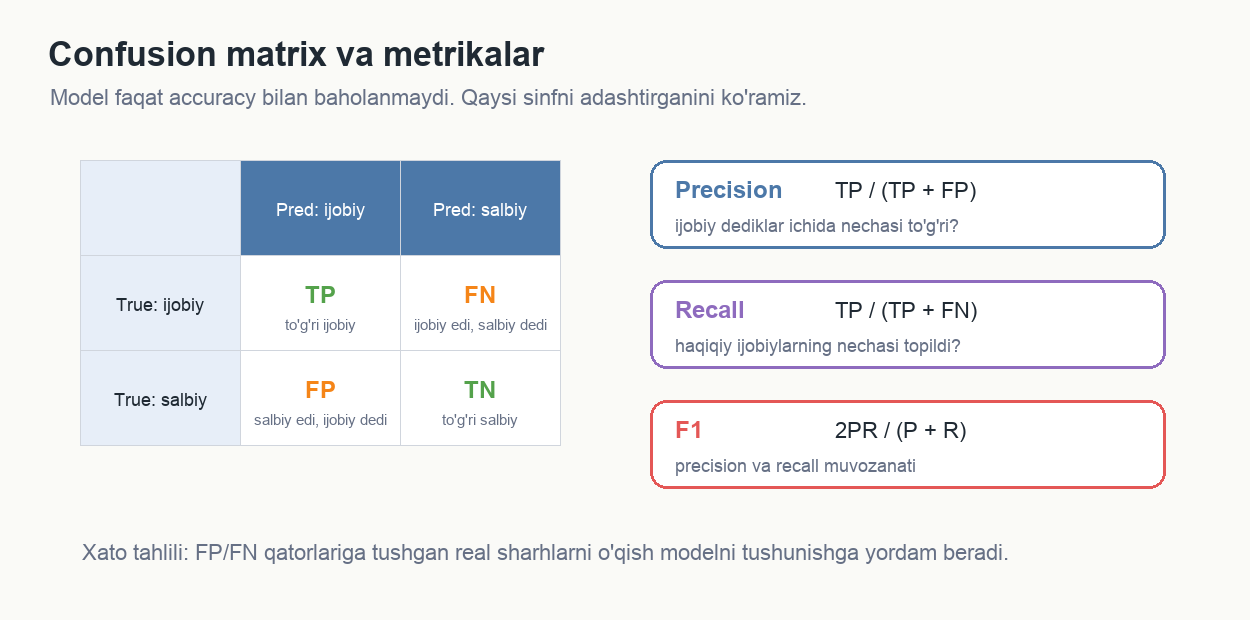


In [31]:
# Namuna: metrikalar — L2 [I3]-slayd (Model B)
# TP=60, TN=820, FP=80, FN=40
TP, TN, FP, FN = 60, 820, 80, 40

accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f'accuracy  = {accuracy:.3f}')
print(f'precision = {precision:.3f}')
print(f'recall    = {recall:.3f}')
print(f'F1        = {f1:.3f}')

# Tekshirish — ma'ruza L2 [I3]-slayd
assert abs(accuracy  - 0.88)   < 0.01
assert abs(precision - 0.4286) < 0.01
assert abs(recall    - 0.60)   < 0.01
assert abs(f1        - 0.50)   < 0.01
# Ma'ruza L2 [I3]-slayd bilan solishtiring
print('\n✓ Ma\'ruza L2 [I3]-slayd tasdiqlandi: A=0.88, P≈0.43, R=0.60, F1=0.50')
print('  Diqqat: accuracy 0.88 yuqori, lekin F1 atigi 0.50 — tengsiz sinflar aldashi!')


accuracy  = 0.880
precision = 0.429
recall    = 0.600
F1        = 0.500

✓ Ma'ruza L2 [I3]-slayd tasdiqlandi: A=0.88, P≈0.43, R=0.60, F1=0.50
  Diqqat: accuracy 0.88 yuqori, lekin F1 atigi 0.50 — tengsiz sinflar aldashi!


### 4E. Birgalikda: haqiqiy modellarni sinov to'plamida baholaymiz


In [32]:
# Birgalikda: sinov to'plamida bashorat
# === SIZNING KODINGIZ (2 qator) ===
# clf_lr va clf_nb bilan X_test uchun bashorat qiling
y_pred_lr = None
y_pred_nb = None


In [34]:
# Logistic Regression bashoratlari
y_pred_lr = clf_lr.predict(X_test)

# Naive Bayes bashoratlari
y_pred_nb = clf_nb.predict(X_test)

print("LogReg bashoratlari soni:", len(y_pred_lr))
print("NB bashoratlari soni:", len(y_pred_nb))

print("Birinchi 5 ta LogReg bashorat:")
print(y_pred_lr[:5])

print("Birinchi 5 ta NB bashorat:")
print(y_pred_nb[:5])


LogReg bashoratlari soni: 6
NB bashoratlari soni: 6
Birinchi 5 ta LogReg bashorat:
['ijobiy' 'salbiy' 'salbiy' 'salbiy' 'ijobiy']
Birinchi 5 ta NB bashorat:
['ijobiy' 'salbiy' 'salbiy' 'salbiy' 'ijobiy']


In [36]:
import numpy as np

assert y_pred_lr is not None and y_pred_nb is not None, (
    'Bashoratlar None. clf.predict(X_test) ni chaqiring.'
)

assert len(y_pred_lr) == X_test.shape[0], (
    'Bashorat uzunligi test hajmiga mos emas.'
)

assert set(np.unique(y_pred_lr)) <= {'ijobiy', 'salbiy'}, (
    "Yorliqlar faqat ijobiy/salbiy."
)

print(
    f'✓ Bashoratlar tayyor: {len(y_pred_lr)} ta (LogReg), '
    f'{len(y_pred_nb)} ta (NB)'
)

✓ Bashoratlar tayyor: 6 ta (LogReg), 6 ta (NB)



=== LogReg ===
              precision    recall  f1-score   support

      ijobiy      1.000     1.000     1.000         3
      salbiy      1.000     1.000     1.000         3

    accuracy                          1.000         6
   macro avg      1.000     1.000     1.000         6
weighted avg      1.000     1.000     1.000         6

Confusion matrix [ijobiy, salbiy]:
[[3 0]
 [0 3]]

=== Naive Bayes ===
              precision    recall  f1-score   support

      ijobiy      1.000     1.000     1.000         3
      salbiy      1.000     1.000     1.000         3

    accuracy                          1.000         6
   macro avg      1.000     1.000     1.000         6
weighted avg      1.000     1.000     1.000         6

Confusion matrix [ijobiy, salbiy]:
[[3 0]
 [0 3]]

F1(ijobiy) — LogReg: 1.000   Naive Bayes: 1.000


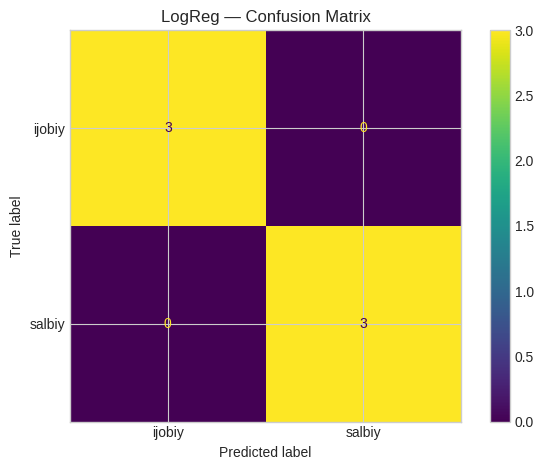

In [37]:
# (Berilgan) hisobot, confusion matrix va grafik
from sklearn.metrics import classification_report, confusion_matrix, f1_score

for name, y_pred in [('LogReg', y_pred_lr), ('Naive Bayes', y_pred_nb)]:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    print('Confusion matrix [ijobiy, salbiy]:')
    print(confusion_matrix(y_test, y_pred, labels=['ijobiy', 'salbiy']))

f1_lr = f1_score(y_test, y_pred_lr, pos_label='ijobiy')
f1_nb = f1_score(y_test, y_pred_nb, pos_label='ijobiy')
print(f'\nF1(ijobiy) — LogReg: {f1_lr:.3f}   Naive Bayes: {f1_nb:.3f}')
assert f1_lr > 0.6 and f1_nb > 0.6, "F1 juda past — modellar o'qitilganini tekshiring."

try:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, labels=['ijobiy', 'salbiy'])
    plt.title('LogReg — Confusion Matrix'); plt.tight_layout(); plt.show()
except Exception as ex:
    print(f'(grafik o\'tkazib yuborildi: {type(ex).__name__})')


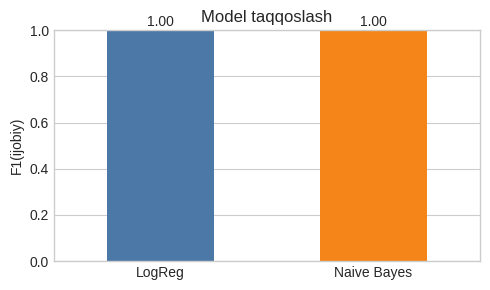

In [38]:
# Vizual taqqoslash: LogReg vs Naive Bayes F1
model_scores = pd.Series({'LogReg': f1_lr, 'Naive Bayes': f1_nb})
ax = model_scores.plot(kind='bar', color=['#4C78A8', '#F58518'], figsize=(5, 3), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel('F1(ijobiy)')
ax.set_title('Model taqqoslash')
for i, v in enumerate(model_scores):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()


### 4F. Birgalikda: xato tahlili — qaysi sharhlar noto'g'ri tasniflandi?


In [40]:
# Birgalikda: xato tahlili
import numpy as np

# === SIZNING KODINGIZ (1-2 qator) ===
# y_test (ro'yxat) va y_pred_lr (numpy massiv) ni solishtirib,
# mos kelmagan indekslarni toping -> wrong_idx (ro'yxat)
wrong_idx = None


In [44]:
# LogReg xato qilgan indekslarni topish
wrong_idx = []

for i in range(len(y_test)):
    if y_test[i] != y_pred_lr[i]:
        wrong_idx.append(i)

print("Xato indekslar:", wrong_idx)
print("Jami xatolar:", len(wrong_idx))


Xato indekslar: []
Jami xatolar: 0


In [46]:
assert wrong_idx is not None, "wrong_idx None. Mos kelmagan indekslarni toping."
assert isinstance(wrong_idx, list), "wrong_idx ro'yxat bo'lishi kerak."

_yt = list(y_test)

assert all(_yt[i] != y_pred_lr[i] for i in wrong_idx), (
    "wrong_idx da to'g'ri tasniflangan element bor — tekshiring."
)

assert len(wrong_idx) < len(_yt), (
    "Model hammasini xato qildi — qayta tekshiring."
)

print(f"✓ Xato tahlili: {len(wrong_idx)}/{len(_yt)} noto'g'ri tasniflandi.")

print("Birinchi 3 ta xato:")

for i in wrong_idx[:3]:
    print(f"  [{_yt[i]}→{y_pred_lr[i]}] {X_test_txt[i][:70]!r}...")

✓ Xato tahlili: 0/6 noto'g'ri tasniflandi.
Birinchi 3 ta xato:


### 4G. Mustaqil: o'z sharhlaringizni tasniflang

Scaffold yo'q — yuqorida o'qitilgan `clf_lr` va `vec` dan foydalaning.


In [47]:
# Mustaqil (siz qilasiz): o'z sharhlaringizni tasniflang
# 1. O'z sharhlaringizni yozing (yoki quyidagi namunadan foydalaning)
# 2. to_str() bilan tozalang
# 3. vec.transform() -> clf_lr.predict()
my_reviews = [
    "Bu mahsulot juda zo'r, hammaga tavsiya qilaman!",
    "Sifatsiz narsa keldi, pulim behuda ketdi, afsus.",
]
# === SIZNING KODINGIZ ===
my_clean = None
my_pred  = None


In [49]:
# Sinash uchun sharhlar
my_reviews = [
    "mahsulot juda yaxshi va sifatli",
    "xizmat juda yomon ekan",
    "yetkazib berish tez bo'ldi",
    "bu ilova menga yoqmadi"
]

# Vektorlash
X_my = vec.transform(my_reviews)

# Bashorat
my_pred = clf_lr.predict(X_my)

print("Sharhlar:")
for review, pred in zip(my_reviews, my_pred):
    print(f"{pred:7} -> {review}")


Sharhlar:
ijobiy  -> mahsulot juda yaxshi va sifatli
ijobiy  -> xizmat juda yomon ekan
salbiy  -> yetkazib berish tez bo'ldi
salbiy  -> bu ilova menga yoqmadi


In [51]:
import numpy as np

assert my_pred is not None, "my_pred None. vec.transform + clf_lr.predict ni qo'llang."

assert len(my_pred) == len(my_reviews), (
    'Bashorat soni sharhlar soniga mos emas.'
)

assert set(np.unique(my_pred)) <= {'ijobiy', 'salbiy'}, (
    "Yorliqlar faqat ijobiy/salbiy."
)

print(f'✓ Mustaqil: {len(my_pred)} sharh tasniflandi -> {list(my_pred)}')

✓ Mustaqil: 4 sharh tasniflandi -> [np.str_('ijobiy'), np.str_('ijobiy'), np.str_('salbiy'), np.str_('salbiy')]


## 5. Yengil loyiha preview — `SentimentClassifier`

4-bo'limda o'rgangan g'oyalarni (TF-IDF + LR/NB + baholash) bitta qayta ishlatiladigan klassga o'raymiz.

Bugun capstone papka arxitekturasini chuqur ochmaymiz. Klass notebook ichida ishlaydi; agar keyin kerak bo'lsa, `SAVE_CAPSTONE_MODULE = True` qilib Python fayliga ham saqlash mumkin.


In [53]:
# m02 SentimentClassifier — inline ta'rif
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import pickle

class SentimentClassifier:
    """TF-IDF + LogReg yoki MultinomialNB asosida ikkilik sentiment tahlili.

    Shartnoma: fit(texts, labels) | predict(text) -> str | predict_proba(text) -> dict
    Consumed by: M4 (FastAPI), Day 16 (agent tool).
    """

    def __init__(self, model: str = 'logreg') -> None:
        if model not in ('logreg', 'nb'):
            raise ValueError("model 'logreg' yoki 'nb' bo'lishi kerak.")
        self._model_name = model
        self._vec  = TfidfVectorizer()
        self._clf  = (LogisticRegression(max_iter=1000) if model == 'logreg'
                      else MultinomialNB(alpha=1.0))
        self._fitted = False

    def _prep(self, text: str) -> str:
        # to_str() — 1-bo'limda aniqlangan mini preprocessor ishlatiladi
        return to_str(text)

    def fit(self, texts: list, labels: list) -> None:
        """Modelni o'qitadi. labels: 'ijobiy' yoki 'salbiy'."""
        if len(texts) != len(labels):
            raise ValueError('texts va labels uzunligi teng bo\'lishi kerak.')
        X = self._vec.fit_transform([self._prep(t) for t in texts])
        self._clf.fit(X, labels)
        self._fitted = True

    def predict(self, text: str) -> str:
        """Bitta matn uchun 'ijobiy' yoki 'salbiy' qaytaradi."""
        if not self._fitted:
            raise ValueError('Avval fit() ni chaqiring.')
        return str(self._clf.predict(self._vec.transform([self._prep(text)]))[0])

    def predict_proba(self, text: str) -> dict:
        """Ehtimolliklar: {'ijobiy': 0.82, 'salbiy': 0.18}."""
        if not self._fitted:
            raise ValueError('Avval fit() ni chaqiring.')
        probs = self._clf.predict_proba(self._vec.transform([self._prep(text)]))[0]
        return {str(c): float(p) for c, p in zip(self._clf.classes_, probs)}

    def save(self, path: str) -> None:
        with open(path, 'wb') as f:
            pickle.dump({'vec': self._vec, 'clf': self._clf,
                         'model_name': self._model_name}, f)

    def load(self, path: str) -> 'SentimentClassifier':
        with open(path, 'rb') as f:
            st = pickle.load(f)
        self._vec, self._clf = st['vec'], st['clf']
        self._model_name = st['model_name']
        self._fitted = True
        return self

print('✓ SentimentClassifier sinfi aniqlandi.')


✓ SentimentClassifier sinfi aniqlandi.


In [54]:
# Shartnoma tekshiruvi
import tempfile, os

clf_m02 = SentimentClassifier(model='logreg')
clf_m02.fit(texts, labels)

# predict -> str
p_pos = clf_m02.predict('Mahsulot juda sifatli, tez yetkazib berishdi, rahmat!')
p_neg = clf_m02.predict("Sifatsiz narsa keldi, sindi, pulim behuda ketdi, afsus.")
assert p_pos == 'ijobiy', f"Ijobiy sharh '{p_pos}' deb tasniflandi — modelni tekshiring."
assert p_neg == 'salbiy', f"Salbiy sharh '{p_neg}' deb tasniflandi — modelni tekshiring."

# predict_proba -> dict, yig'indi = 1
pr = clf_m02.predict_proba("Mahsulot zo'r va sifatli!")
assert set(pr.keys()) == {'ijobiy', 'salbiy'}, "predict_proba kalitlari: {'ijobiy','salbiy'}"
assert abs(sum(pr.values()) - 1.0) < 1e-6, "Ehtimolliklar yig'indisi 1 bo'lishi kerak."

# save / load roundtrip
_tmp = os.path.join(tempfile.gettempdir(), 'm02_test.pkl')
clf_m02.save(_tmp)
clf2 = SentimentClassifier().load(_tmp)
assert clf2.predict("Zo'r mahsulot!") == clf_m02.predict("Zo'r mahsulot!"), (
    'save/load dan keyin bashorat mos kelmadi.'
)

print('✓ SentimentClassifier barcha shartnoma tekshiruvlaridan o\'tdi!')
print(f'  predict(ijobiy sharh) = {p_pos}   predict(salbiy sharh) = {p_neg}')
print(f"  predict_proba = { {k: round(v,3) for k,v in pr.items()} }")


✓ SentimentClassifier barcha shartnoma tekshiruvlaridan o'tdi!
  predict(ijobiy sharh) = ijobiy   predict(salbiy sharh) = salbiy
  predict_proba = {'ijobiy': 0.587, 'salbiy': 0.413}


In [55]:
# Ixtiyoriy: m02 ni faylga saqlash (SAVE_CAPSTONE_MODULE = True bo'lsa)
if SAVE_CAPSTONE_MODULE:
    module_text = """
import pickle
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

_APO = re.compile(r"['’‘ʼʻ]")
_TOK = re.compile(r"[a-z][a-z']*")
_STOP = {'va', 'bu', 'bir', 'ham', 'lekin', 'uchun', 'bilan', 'ga', 'da',
         'ni', 'dan', 'ning', 'men', 'sen', 'biz', 'siz', 'ular'}

def to_str(text):
    t = _APO.sub("'", text.lower())
    toks = [w for w in _TOK.findall(t) if w not in _STOP and len(w) > 1]
    return " ".join(toks) if toks else ""

class SentimentClassifier:
    def __init__(self, model='logreg'):
        if model not in ('logreg', 'nb'):
            raise ValueError("model 'logreg' yoki 'nb' bo'lishi kerak")
        self._model_name = model
        self._vec = TfidfVectorizer()
        self._clf = LogisticRegression(max_iter=1000) if model == 'logreg' else MultinomialNB(alpha=1.0)
        self._fitted = False

    def fit(self, texts, labels):
        if len(texts) != len(labels):
            raise ValueError('texts va labels uzunligi teng bo'lishi kerak')
        X = self._vec.fit_transform([to_str(t) for t in texts])
        self._clf.fit(X, labels)
        self._fitted = True

    def predict(self, text):
        if not self._fitted:
            raise ValueError('Avval fit() ni chaqiring')
        return str(self._clf.predict(self._vec.transform([to_str(text)]))[0])

    def predict_proba(self, text):
        if not self._fitted:
            raise ValueError('Avval fit() ni chaqiring')
        probs = self._clf.predict_proba(self._vec.transform([to_str(text)]))[0]
        return {str(c): float(p) for c, p in zip(self._clf.classes_, probs)}

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({'vec': self._vec, 'clf': self._clf, 'model_name': self._model_name}, f)

    def load(self, path):
        with open(path, 'rb') as f:
            state = pickle.load(f)
        self._vec = state['vec']
        self._clf = state['clf']
        self._model_name = state['model_name']
        self._fitted = True
        return self
"""
    path = Path('m02_sentiment_classifier.py')
    path.write_text(module_text.strip() + chr(10), encoding='utf-8')
    print(f'✓ m02 saqlandi: {path}')
else:
    print('SAVE_CAPSTONE_MODULE = False — fayl yozilmadi (kurs rejimi).')
    print("SentimentClassifier sinfi bu notebookda (5-bo'limda) aniqlangan va tayyor.")


SAVE_CAPSTONE_MODULE = False — fayl yozilmadi (kurs rejimi).
SentimentClassifier sinfi bu notebookda (5-bo'limda) aniqlangan va tayyor.


## 6. Tadqiqot savoli + yakun

**Savol:** Kichik o'zbek korpusida LogReg yoki Naive Bayes — qaysi biri yaxshiroq
ishlaydi? Javob L2 [O]-slaydda muhokama qilingan — endi raqam bilan tekshiring.


In [59]:
from sklearn.metrics import f1_score

# Logistic Regression
y_pred_lr = clf_lr.predict(X_test)

# Naive Bayes
y_pred_nb = clf_nb.predict(X_test)

# Macro F1
_f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='macro'
)

_f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='macro'
)

print(f'LogReg      macro-F1 = {_f1_lr:.3f}')
print(f'Naive Bayes macro-F1 = {_f1_nb:.3f}')
print(f'Farq                 = {abs(_f1_lr - _f1_nb):.3f}')

print()
print("Mulohaza:")
print("Kichik korpuslarda Naive Bayes ko'pincha barqaror ishlaydi.")
print("Logistic Regression esa ma'lumotlar soni ortgani sari")
print("ko'pincha yaxshiroq natija beradi.")
print("Aniq xulosa uchun cross-validation qo'llash tavsiya etiladi.")


LogReg      macro-F1 = 1.000
Naive Bayes macro-F1 = 1.000
Farq                 = 0.000

Mulohaza:
Kichik korpuslarda Naive Bayes ko'pincha barqaror ishlaydi.
Logistic Regression esa ma'lumotlar soni ortgani sari
ko'pincha yaxshiroq natija beradi.
Aniq xulosa uchun cross-validation qo'llash tavsiya etiladi.


## Yakun

**Bugun nimalar qildik:**
- ✓ Uzum Market sharhlarini ijobiy/salbiy ga binarizatsiya qildik (reyting 3 tashlandi)
- ✓ Mini TextPreprocessor + TF-IDF + train/test ajratdik
- ✓ Naive Bayes ni qo'lda hisoblab, L2 [I2]-slayd natijasini tasdiqladik (nisbat=3.375)
- ✓ LogisticRegression va MultinomialNB ni o'qitdik
- ✓ Precision/recall/F1 va confusion matrix bilan baholadik (L2 [I3]: F1=0.50)
- ✓ `SentimentClassifier` klassining yengil notebook versiyasini ko'rdik

**Keyingi amaliyot (P3 — so'z embeddinglari):**
Tayyor embeddinglar (`cc_uz_100k.kv`) → kosinus o'xshashlik → m03 PretrainedEmbedder
Birinchi assert: `abs(cos_val - 0.667) < 1e-3` (L3 [I2]-slayd)


**Chiqish chiptasi:** Bugun eng tushunarsiz qolgan narsa nima?
*(Quyidagi katakka yozing — keyingi darsda muhokama qilamiz.)*
